In [ ]:
import kagglehub
import pandas as pd
import numpy as np

# Fijamos semilla para reproducibilidad
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Descarga del dataset
path = kagglehub.dataset_download("arianazmoudeh/airbnbopendata")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'airbnbopendata' dataset.
Path to dataset files: /kaggle/input/airbnbopendata


In [ ]:
import os

# Listamos los archivos descargados para saber el nombre exacto del CSV
print(os.listdir(path))

['Airbnb_Open_Data.csv']


In [ ]:
# Cargamos el CSV (ajusta el nombre según lo que arroje el listdir anterior)
df = pd.read_csv(f"{path}/Airbnb_Open_Data.csv")

# Dimensiones del dataset
print("Filas:", df.shape[0])
print("Columnas:", df.shape[1])

Filas: 102599
Columnas: 26


/tmp/ipykernel_835/1338851031.py:2: DtypeWarning: Columns (25) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f"{path}/Airbnb_Open_Data.csv")


In [ ]:
df.head()

,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,$193,10.0,9.0,10/19/2021,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like...,NaN
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,$28,30.0,45.0,5/21/2022,0.38,4.0,2.0,228.0,Pet friendly but please confirm with me if the...,NaN
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,...,$124,3.0,0.0,NaN,NaN,5.0,1.0,352.0,"I encourage you to use my kitchen, cooking and...",NaN
3,1002755,NaN,85098326012,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,...,$74,30.0,270.0,7/5/2019,4.64,4.0,1.0,322.0,NaN,NaN
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,...,$41,10.0,9.0,11/19/2018,0.10,3.0,1.0,289.0,"Please no smoking in the house, porch or on th...",NaN


In [ ]:
# Tipos de datos y nulos por columna
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102599 entries, 0 to 102598
Data columns (total 26 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   id                              102599 non-null  int64  
 1   NAME                            102349 non-null  object 
 2   host id                         102599 non-null  int64  
 3   host_identity_verified          102310 non-null  object 
 4   host name                       102193 non-null  object 
 5   neighbourhood group             102570 non-null  object 
 6   neighbourhood                   102583 non-null  object 
 7   lat                             102591 non-null  float64
 8   long                            102591 non-null  float64
 9   country                         102067 non-null  object 
 10  country code                    102468 non-null  object 
 11  instant_bookable                102494 non-null  object 
 12  cancellation_pol

In [ ]:
# Resumen de nulos ordenado de mayor a menor
df.isnull().sum().sort_values(ascending=False)

,0
license,102597
house_rules,52131
last review,15893
reviews per month,15879
country,532
availability 365,448
minimum nights,409
host name,406
review rate number,326
calculated host listings count,319


In [ ]:
# Revisamos valores únicos de las columnas categóricas clave para detectar
# inconsistencias de texto (typos, mayúsculas/minúsculas, etc.)
cat_cols = ['neighbourhood group', 'room type', 'cancellation_policy',
            'instant_bookable', 'host_identity_verified', 'country', 'country code']

for col in cat_cols:
    print(f"--- {col} ---")
    print(df[col].value_counts(dropna=False))
    print()

--- neighbourhood group ---
neighbourhood group
Manhattan        43792
Brooklyn         41842
Queens           13267
Bronx             2712
Staten Island      955
NaN                 29
manhatan             1
brookln              1
Name: count, dtype: int64

--- room type ---
room type
Entire home/apt    53701
Private room       46556
Shared room         2226
Hotel room           116
Name: count, dtype: int64

--- cancellation_policy ---
cancellation_policy
moderate    34343
strict      34106
flexible    34074
NaN            76
Name: count, dtype: int64

--- instant_bookable ---
instant_bookable
False    51474
True     51020
NaN        105
Name: count, dtype: int64

--- host_identity_verified ---
host_identity_verified
unconfirmed    51200
verified       51110
NaN              289
Name: count, dtype: int64

--- country ---
country
United States    102067
NaN                 532
Name: count, dtype: int64

--- country code ---
country code
US     102468
NaN       131
Name: count, dtype: 

In [ ]:
# Vistazo rápido a 'price' y 'service fee' para ver el formato exacto
print(df['price'].dropna().unique()[:10])
print(df['service fee'].dropna().unique()[:10])

['$966 ' '$142 ' '$620 ' '$368 ' '$204 ' '$577 ' '$71 ' '$1,060 '
 '$1,018 ' '$291 ']
['$193 ' '$28 ' '$124 ' '$74 ' '$41 ' '$115 ' '$14 ' '$212 ' '$204 '
 '$58 ']


In [ ]:
# Revisemos también duplicados exactos y duplicados por 'id'
print("Filas duplicadas exactas:", df.duplicated().sum())
print("IDs duplicados:", df['id'].duplicated().sum())

Filas duplicadas exactas: 541
IDs duplicados: 541


In [ ]:
# --- 1. Eliminar duplicados exactos ---
df = df.drop_duplicates()
print("Filas después de eliminar duplicados:", df.shape[0])

Filas después de eliminar duplicados: 102058


In [ ]:
# --- 2. Corregir typos en 'neighbourhood group' ---
df['neighbourhood group'] = df['neighbourhood group'].replace({
    'manhatan': 'Manhattan',
    'brookln': 'Brooklyn'
})
print(df['neighbourhood group'].value_counts(dropna=False))

neighbourhood group
Manhattan        43558
Brooklyn         41631
Queens           13197
Bronx             2694
Staten Island      949
NaN                 29
Name: count, dtype: int64


In [ ]:
# --- 3. Limpiar 'price' y 'service fee': quitar '$', ',', espacios y convertir a float ---
for col in ['price', 'service fee']:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace('$', '', regex=False)
        .str.replace(',', '', regex=False)
        .str.strip()
    )
    df[col] = pd.to_numeric(df[col], errors='coerce')  # los NaN originales se mantienen como NaN

print(df[['price', 'service fee']].describe())

               price    service fee
count  101811.000000  101785.000000
mean      625.355580     125.039249
std       331.672649      66.325905
min        50.000000      10.000000
25%       340.000000      68.000000
50%       625.000000     125.000000
75%       913.000000     183.000000
max      1200.000000     240.000000


In [ ]:
# --- 4. Renombrar columnas con espacios a snake_case (buena práctica, evita errores futuros) ---
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
print(df.columns.tolist())

['id', 'name', 'host_id', 'host_identity_verified', 'host_name', 'neighbourhood_group', 'neighbourhood', 'lat', 'long', 'country', 'country_code', 'instant_bookable', 'cancellation_policy', 'room_type', 'construction_year', 'price', 'service_fee', 'minimum_nights', 'number_of_reviews', 'last_review', 'reviews_per_month', 'review_rate_number', 'calculated_host_listings_count', 'availability_365', 'house_rules', 'license']


In [ ]:
# --- 5. Revisar nulos restantes tras la limpieza ---
df.isnull().sum().sort_values(ascending=False)

,0
license,102056
house_rules,51842
last_review,15832
reviews_per_month,15818
country,532
availability_365,448
host_name,404
minimum_nights,400
calculated_host_listings_count,319
review_rate_number,319


In [ ]:
# Columnas actuales tras el renombrado
print(df.columns.tolist())

['id', 'name', 'host_id', 'host_identity_verified', 'host_name', 'neighbourhood_group', 'neighbourhood', 'lat', 'long', 'country', 'country_code', 'instant_bookable', 'cancellation_policy', 'room_type', 'construction_year', 'price', 'service_fee', 'minimum_nights', 'number_of_reviews', 'last_review', 'reviews_per_month', 'review_rate_number', 'calculated_host_listings_count', 'availability_365', 'house_rules', 'license']


In [ ]:
# Revisemos 'minimum_nights' y 'availability_365' — clásicos candidatos a outliers
print(df['minimum_nights'].describe())
print()
print(df['availability_365'].describe())

count    101658.000000
mean          8.126640
std          30.616698
min       -1223.000000
25%           2.000000
50%           3.000000
75%           5.000000
max        5645.000000
Name: minimum_nights, dtype: float64

count    101610.000000
mean        141.043992
std         135.429156
min         -10.000000
25%           3.000000
50%          96.000000
75%         268.000000
max        3677.000000
Name: availability_365, dtype: float64


In [ ]:
# Valores fuera de rango lógico:
# minimum_nights negativo no tiene sentido; availability_365 no debería superar 365
print("minimum_nights negativos:", (df['minimum_nights'] < 0).sum())
print("availability_365 > 365:", (df['availability_365'] > 365).sum())
print("availability_365 negativos:", (df['availability_365'] < 0).sum())

minimum_nights negativos: 13
availability_365 > 365: 2754
availability_365 negativos: 431


In [ ]:
# Decisión sobre columnas casi vacías / poco útiles
# license: 102597 nulos de ~102k filas -> se elimina
# house_rules: texto libre, ~51% nulo -> se elimina del análisis cuantitativo
#              (no aporta a variables categóricas/continuas estructuradas)
# country / country_code: prácticamente constantes -> se eliminan (no distinguen nada)
df = df.drop(columns=['license', 'house_rules', 'country', 'country_code'])
print(df.shape)

(102058, 22)


In [ ]:
# Cuantifiquemos cuántas filas están afectadas por estos valores imposibles
print("minimum_nights negativos:", (df['minimum_nights'] < 0).sum())
print("minimum_nights > 365 (poco realista para un Airbnb):", (df['minimum_nights'] > 365).sum())
print()
print("availability_365 negativos:", (df['availability_365'] < 0).sum())
print("availability_365 > 365:", (df['availability_365'] > 365).sum())

minimum_nights negativos: 13
minimum_nights > 365 (poco realista para un Airbnb): 35

availability_365 negativos: 431
availability_365 > 365: 2754


In [ ]:
# Criterio de limpieza (a justificar en el informe):
# - availability_365 tiene un límite físico claro (0-365). Los valores fuera de ese
#   rango son errores de captura -> se corrigen a NaN (no se puede "adivinar" el valor real).
df.loc[(df['availability_365'] < 0) | (df['availability_365'] > 365), 'availability_365'] = np.nan

# - minimum_nights negativo no tiene sentido físico -> se pasa a NaN.
#   Valores muy altos (ej. >365) sí pueden ser reales (alquileres de largo plazo),
#   así que NO los tocamos aquí; se evaluarán con criterio cuantitativo (IQR/z-score)
#   en el paso de detección de outliers, no como error de captura.
df.loc[df['minimum_nights'] < 0, 'minimum_nights'] = np.nan

print(df[['minimum_nights', 'availability_365']].describe())

       minimum_nights  availability_365
count   101645.000000      98425.000000
mean         8.147120        134.528484
std         30.341361        129.805264
min          1.000000          0.000000
25%          2.000000          2.000000
50%          3.000000         90.000000
75%          5.000000        254.000000
max       5645.000000        365.000000


In [ ]:
# --- Detección de outliers con criterio cuantitativo (IQR) ---
def contar_outliers_iqr(serie, nombre):
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1
    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr
    outliers = serie[(serie < lim_inf) | (serie > lim_sup)]
    print(f"{nombre}: límites [{lim_inf:.1f}, {lim_sup:.1f}] -> {outliers.shape[0]} outliers")
    return lim_inf, lim_sup

for col in ['price', 'service_fee', 'minimum_nights', 'number_of_reviews', 'availability_365']:
    contar_outliers_iqr(df[col].dropna(), col)

price: límites [-519.5, 1772.5] -> 0 outliers
service_fee: límites [-104.5, 355.5] -> 0 outliers
minimum_nights: límites [-2.5, 9.5] -> 18240 outliers
number_of_reviews: límites [-44.0, 76.0] -> 11120 outliers
availability_365: límites [-376.0, 632.0] -> 0 outliers


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

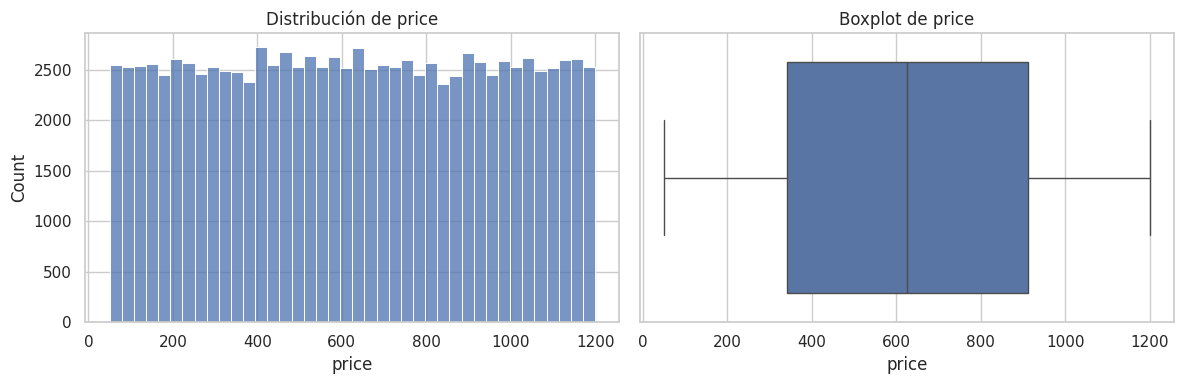

In [ ]:
# --- Univariada: distribución de precios ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['price'].dropna(), bins=40, ax=axes[0])
axes[0].set_title('Distribución de price')

sns.boxplot(x=df['price'].dropna(), ax=axes[1])
axes[1].set_title('Boxplot de price')
plt.tight_layout()
plt.show()

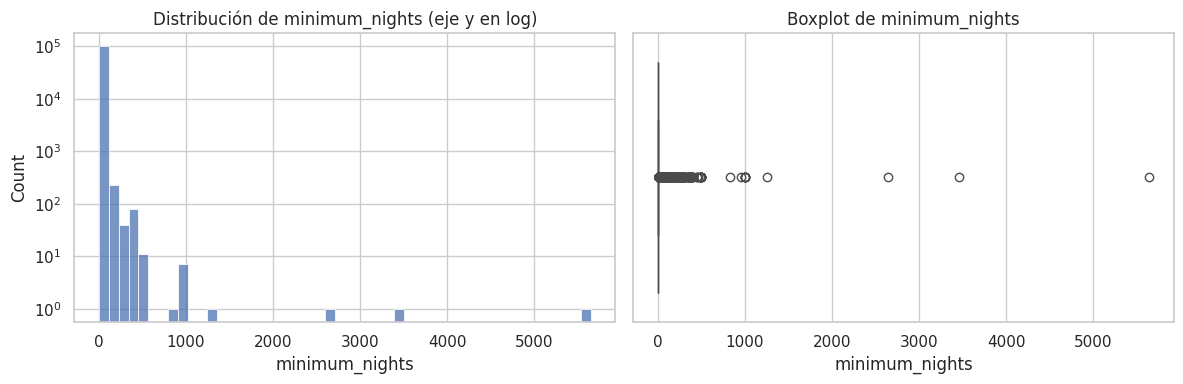

In [ ]:
# --- Univariada: minimum_nights (escala log por su asimetría) ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['minimum_nights'].dropna(), bins=50, ax=axes[0])
axes[0].set_yscale('log')
axes[0].set_title('Distribución de minimum_nights (eje y en log)')

sns.boxplot(x=df['minimum_nights'].dropna(), ax=axes[1])
axes[1].set_title('Boxplot de minimum_nights')
plt.tight_layout()
plt.show()

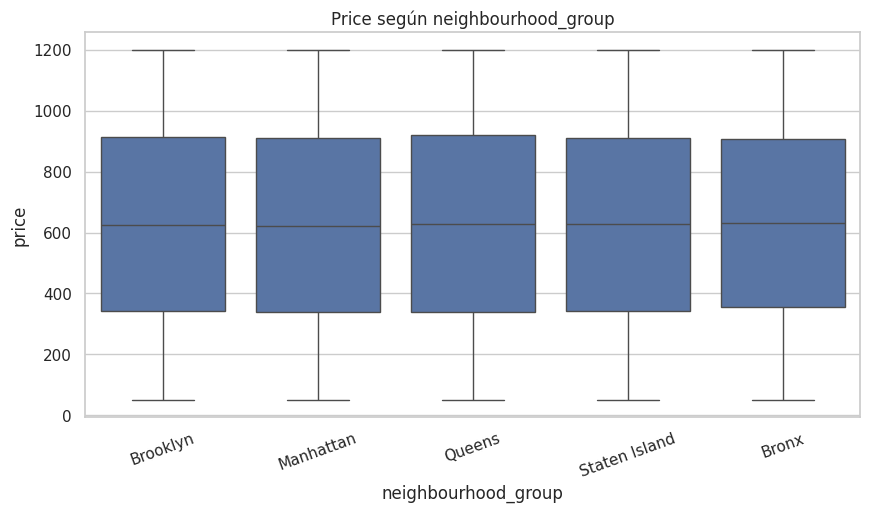

In [ ]:
# --- Bivariada: price según neighbourhood_group ---
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='neighbourhood_group', y='price')
plt.title('Price según neighbourhood_group')
plt.xticks(rotation=20)
plt.show()

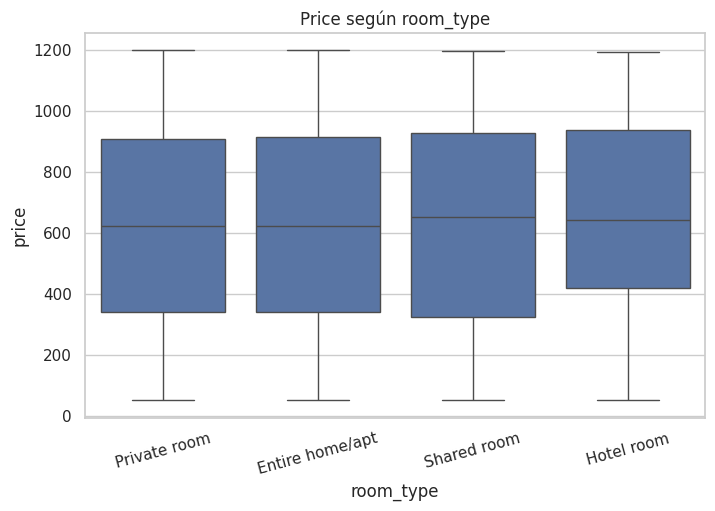

In [ ]:
# --- Bivariada: price según room_type ---
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='room_type', y='price')
plt.title('Price según room_type')
plt.xticks(rotation=15)
plt.show()

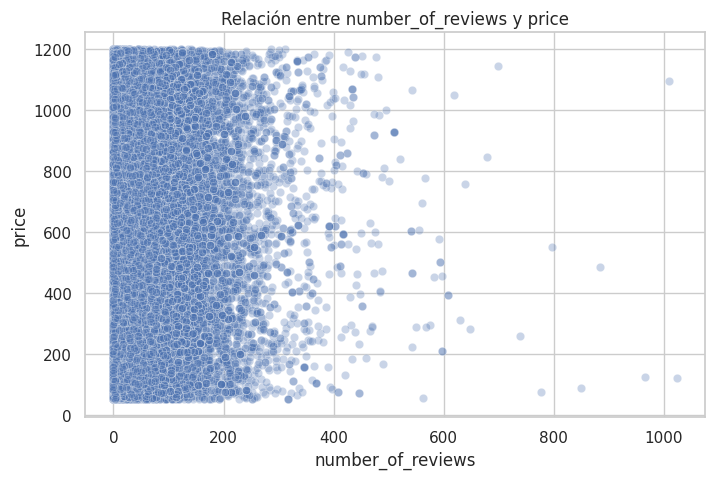

In [ ]:
# --- Bivariada: number_of_reviews vs price (scatter) ---
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='number_of_reviews', y='price', alpha=0.3)
plt.title('Relación entre number_of_reviews y price')
plt.show()